# 01: Data Ingestion

**Project:** Multi-Disease Outbreak Forecasting with Temporal Deep Learning
**Research Question:** Can we accurately forecast short-term disease incidence (4–8 weeks ahead) across Canadian provinces using historical weekly case counts, and does a deep learning approach (LSTM or Transformer-based) outperform classical baselines such as ARIMA or Prophet?
**End User:** Provincial and federal public health agencies (e.g., PHAC), epidemiologists, health system planners.

This notebook does several things:
1. It downloads the normalized CANDID dataset from the IIDDA REST API, caches it locally, and performs an initial inspection of its structure using three diseases.
2. It downloads the PHAC dataset for those three diseases as a cross validation against our CANDID dataset (PHAC data is annual, while CANDID is weekly).
3. After data cross validation, we make a decision on go forward with data and proceed with EDA.

Note: the data folders are in the `.gitignore` because of the sheer size of the raw CSV. Each team member should run this notebook once to cache the file locally.

**Primary Dataset:** `canmod-cdi-normalized` — Canadian Harmonized and Normalized Communicable Disease Incidence Data  
**API:** https://math.mcmaster.ca/iidda/api/  
**Paper:** Earn et al. (2024), *PLOS Global Public Health*


**Secondary Dataset:** `phac-data` - Public Health Agency of Canada Large Data Extract
**URL:** Notifiable Disease Dataset Extraction: https://diseases.canada.ca/notifiable/extract-dataset

In [1]:
import sys
sys.path.append('../src')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from data_loader import get_dataset_ids, load_candid, filter_disease_province

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

## 1. Explore Available CANDID Datasets

In [2]:
all_ids = get_dataset_ids()
print(f"Total datasets available: {len(all_ids)}\n")

harmonized = [d for d in all_ids if 'harmonized' in d or 'canmod' in d]
print("Analysis-ready (harmonized / canmod) datasets:")
for d in harmonized:
    print(f"  {d}")

Total datasets available: 143

Analysis-ready (harmonized / canmod) datasets:
  canmod-pop-normalized
  cdi_sk_1910-1927_mn_harmonized
  cdi_man_2004-17_mn_harmonized
  cdi_ca_2001-2006_qr_prov_ccdr_harmonized
  canmod-mort-normalized
  cdi_ca_1924-55_wk_prov_dbs_statcan_harmonized
  canmod-mort-harmonized
  cdi_on_1990-2021_wk_harmonized
  cdi_ca_1979-89_4wk_prov_harmonized
  cdi_ca_1990-2001_quart_prov_harmonized
  cdi_ca_1975-78_wk_prov_harmonized
  cdi_ab_2004-19_wk_harmonized
  cdi_on_1939-1989_wk_harmonized
  cdi_ca_1968-72_wk_prov_harmonized
  cdi_ca_1964-67_wk_prov_harmonized
  cdi_qc_1915-1925_mn_harmonized
  cdi_on_1940-1947_mn_harmonized
  cdi_on_1903-1939_mn_harmonized
  cdi_ca_1956-63_1973-74_wk_prov_harmonized
  canmod-cdi-normalized
  canmod-time-scale-cross-check
  canmod-cdi-unharmonized
  canmod-location-cross-check
  canmod-disease-cross-check
  canmod-cdi-harmonized
  pop_ca_1871-2021_harmonized


## 2. Download and Cache the Normalized CANDID Dataset

In [3]:
CACHE_PATH = '../data/raw/canmod-cdi-normalized.csv'

df = load_candid(cache_path=CACHE_PATH)
print(f"Shape: {df.shape}")
df.head(3)

Loaded 934,010 rows from cache: ../data/raw/canmod-cdi-normalized.csv
Shape: (934010, 21)


,iso_3166,iso_3166_2,period_start_date,period_end_date,disease,nesting_disease,basal_disease,cases_this_period,location,location_type,time_scale,historical_disease,historical_disease_family,historical_disease_subclass,days_this_period,period_mid_date,population,record_origin,original_dataset_id,digitization_id,scan_id
0,CA,CA-ON,1903-01-01,1903-01-31,smallpox,NaN,smallpox,196.0,ONT.,province,mo,Small-pox,NaN,NaN,31,1903-01-16,2252721,historical,cdi_on_1903-1939_mn,cdi_mort_on_1903-1939_mn,cdi_on_1903-1939_mn
1,CA,CA-ON,1903-01-01,1903-01-31,scarlet-fever,NaN,scarlet-fever,500.0,ONT.,province,mo,Scarlatina,NaN,NaN,31,1903-01-16,2252721,historical,cdi_on_1903-1939_mn,cdi_mort_on_1903-1939_mn,cdi_on_1903-1939_mn
2,CA,CA-ON,1903-01-01,1903-01-31,diphtheria,NaN,diphtheria,510.0,ONT.,province,mo,Diphtheria,NaN,NaN,31,1903-01-16,2252721,historical,cdi_on_1903-1939_mn,cdi_mort_on_1903-1939_mn,cdi_on_1903-1939_mn


## 3. Dataset Schema

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 934010 entries, 0 to 934009
Data columns (total 21 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   iso_3166                     934010 non-null  object        
 1   iso_3166_2                   934010 non-null  object        
 2   period_start_date            934010 non-null  datetime64[ns]
 3   period_end_date              934010 non-null  datetime64[ns]
 4   disease                      934010 non-null  object        
 5   nesting_disease              457602 non-null  object        
 6   basal_disease                934010 non-null  object        
 7   cases_this_period            933977 non-null  float64       
 8   location                     934010 non-null  object        
 9   location_type                934010 non-null  object        
 10  time_scale                   934010 non-null  object        
 11  historical_disease        

## 4. Coverage Summary

In [5]:
print(f"Date range:    {df['period_start_date'].min().date()}  →  {df['period_start_date'].max().date()}")
print(f"Unique diseases: {df['disease'].nunique()}")
print(f"Provinces/territories: {df['iso_3166_2'].nunique()}")
print()

print("Records by time scale:")
print(df['time_scale'].value_counts().to_string())
print()

print("Records by province:")
print(df.groupby('iso_3166_2').size().sort_values(ascending=False).to_string())

Date range:    1903-01-01  →  2021-12-26
Unique diseases: 317
Provinces/territories: 13

Records by time scale:
time_scale
wk     829689
mo      82267
qr      20967
2wk       567
3qr       520

Records by province:
iso_3166_2
CA-ON    177484
CA-AB    150084
CA-MB     79785
CA-NS     77242
CA-SK     77223
CA-BC     71671
CA-QC     66866
CA-NB     65594
CA-PE     59116
CA-NL     46766
CA-NT     30949
CA-YT     30704
CA-NU       526


## 5. Top Diseases by Record Count

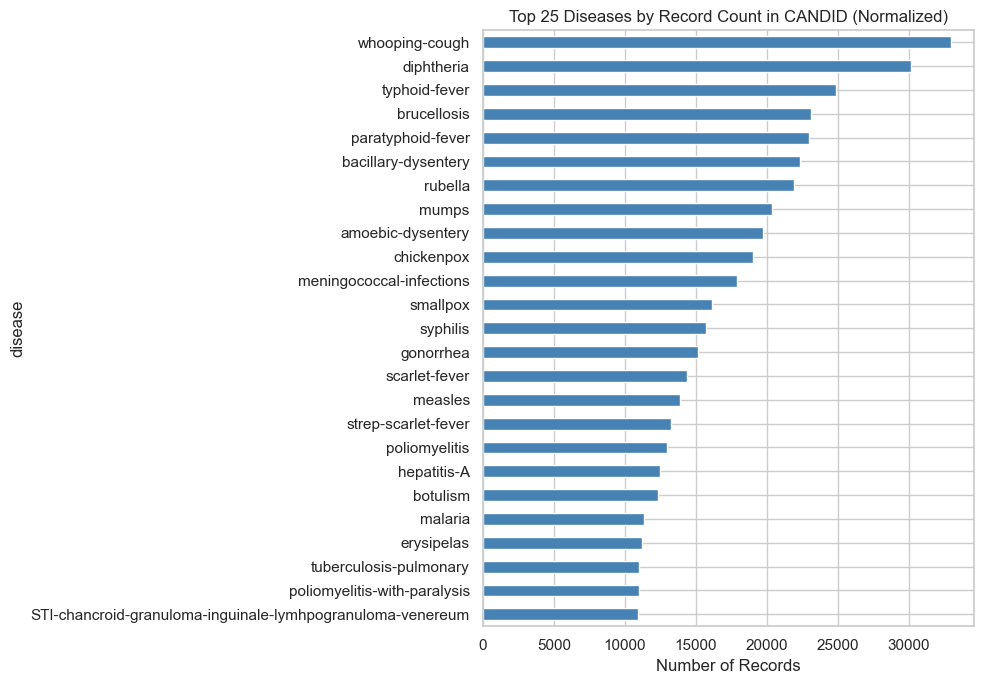

In [6]:
top_diseases = df['disease'].value_counts().head(25)

fig, ax = plt.subplots(figsize=(10, 7))
top_diseases.plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Number of Records')
ax.set_title('Top 25 Diseases by Record Count in CANDID (Normalized)')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../reports/figures/top_diseases_record_count.png', dpi=150)
plt.show()

## 6. Disease Coverage by Time

A brief look at the disease representation by time span to ensure we can identity recurrences or outbreaks in the data. We've filtered it to the top twenty-five diseases

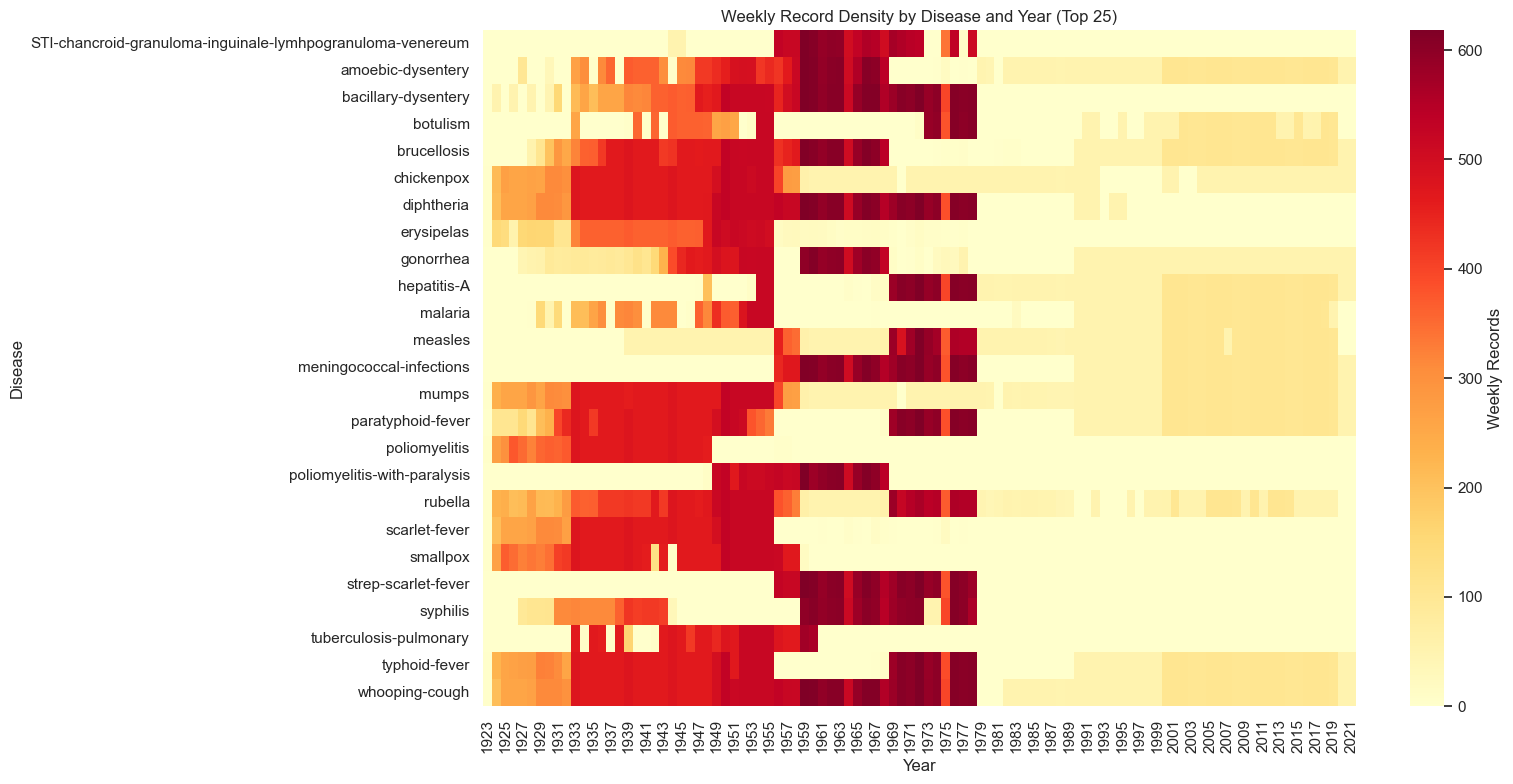

In [7]:
weekly = df[df['time_scale'] == 'wk'].copy()
weekly['year'] = weekly['period_start_date'].dt.year

disease_year = weekly.groupby(['disease', 'year']).size().unstack(fill_value=0)
disease_year = disease_year.loc[disease_year.index.isin(top_diseases.index)]

fig, ax = plt.subplots(figsize=(16, 8))
sns.heatmap(disease_year, ax=ax, cmap='YlOrRd', cbar_kws={'label': 'Weekly Records'})
ax.set_title('Weekly Record Density by Disease and Year (Top 25)')
ax.set_xlabel('Year')
ax.set_ylabel('Disease')
plt.tight_layout()
plt.savefig('../reports/figures/disease_year_heatmap.png', dpi=150)
plt.show()

## 7. Focus Diseases — Coverage Check

Our three target diseases are **influenza**, **pertussis (whooping cough)**, and **measles**. All three are confirmed present in CANDID. We verify weekly record density and date ranges for each below.

In [8]:
focus_diseases = ['influenza', 'whooping-cough', 'measles']

for disease in focus_diseases:
    subset = df[df['disease'] == disease]
    wk = subset[subset['time_scale'] == 'wk']
    print(f"{disease}:")
    print(f"  Total records: {len(subset):,}  |  Weekly records: {len(wk):,}")
    print(f"  Date range: {subset['period_start_date'].min().date()} → {subset['period_start_date'].max().date()}")
    print(f"  Provinces: {sorted(subset['iso_3166_2'].unique())}")
    print()

influenza:
  Total records: 5,164  |  Weekly records: 4,900
  Date range: 1910-01-01 → 2021-12-26
  Provinces: ['CA-AB', 'CA-BC', 'CA-MB', 'CA-NB', 'CA-NL', 'CA-NS', 'CA-ON', 'CA-PE', 'CA-QC', 'CA-SK']

whooping-cough:
  Total records: 32,950  |  Weekly records: 30,059
  Date range: 1903-01-01 → 2021-12-26
  Provinces: ['CA-AB', 'CA-BC', 'CA-MB', 'CA-NB', 'CA-NL', 'CA-NS', 'CA-NT', 'CA-NU', 'CA-ON', 'CA-PE', 'CA-QC', 'CA-SK', 'CA-YT']

measles:
  Total records: 13,859  |  Weekly records: 11,164
  Date range: 1903-01-01 → 2019-12-22
  Provinces: ['CA-AB', 'CA-BC', 'CA-MB', 'CA-NB', 'CA-NL', 'CA-NS', 'CA-NT', 'CA-NU', 'CA-ON', 'CA-PE', 'CA-QC', 'CA-SK', 'CA-YT']



## 8. Sanity Check: Whooping Cough (Pertussis) Weekly Incidence

Pertussis has the largest record count of our focus diseases and shows notable geographic variation in the 1990s — a key finding from Earn et al. (2024). We plot Ontario and Quebec to visualize this pattern.

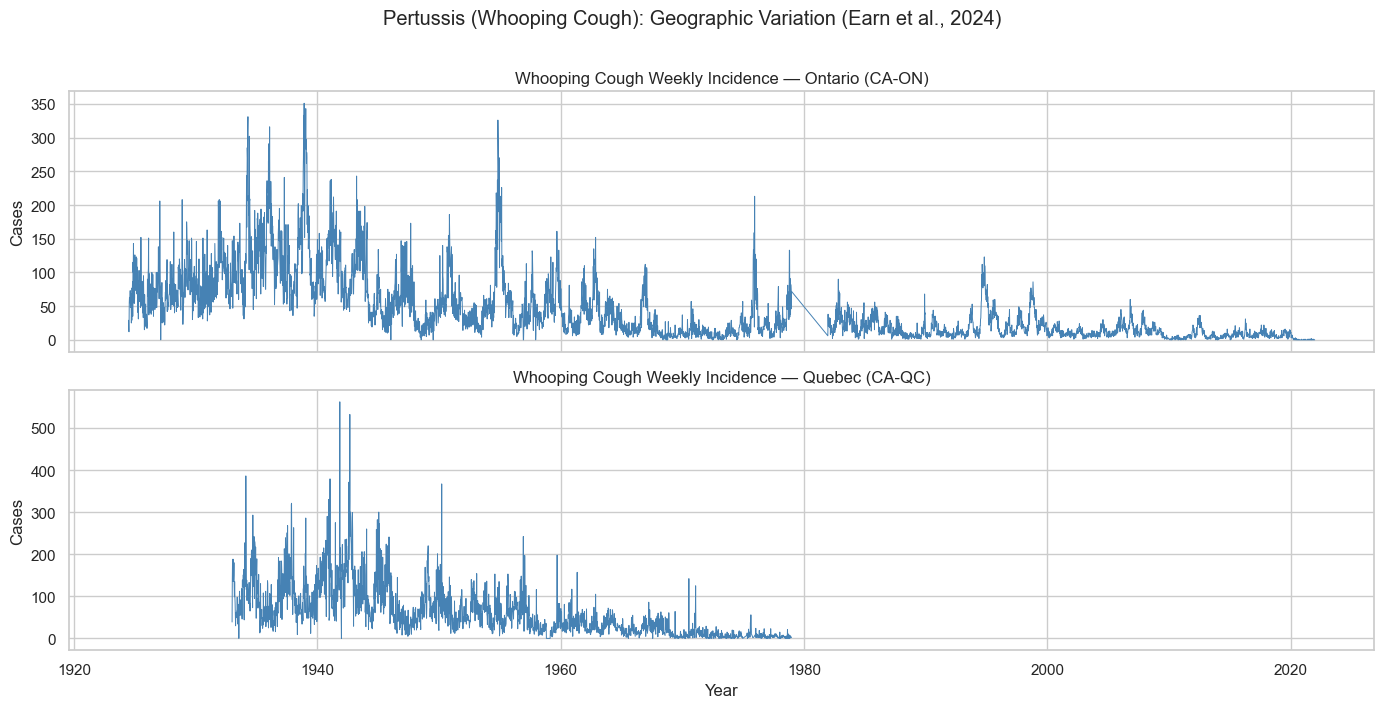

Ontario records: 4,911
Quebec records:  2,338


In [9]:
wc_on = filter_disease_province(df, disease='whooping-cough', province_code='CA-ON', time_scale='wk')
wc_qc = filter_disease_province(df, disease='whooping-cough', province_code='CA-QC', time_scale='wk')

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

for ax, prov_df, label in zip(axes, [wc_on, wc_qc], ['Ontario (CA-ON)', 'Quebec (CA-QC)']):
    ax.plot(prov_df['period_start_date'], prov_df['cases_this_period'], linewidth=0.7, color='steelblue')
    ax.set_ylabel('Cases')
    ax.set_title(f'Whooping Cough Weekly Incidence — {label}')

axes[-1].set_xlabel('Year')
plt.suptitle('Pertussis (Whooping Cough): Geographic Variation (Earn et al., 2024)', y=1.01)
plt.tight_layout()
plt.savefig('../reports/figures/whooping_cough_on_qc_weekly.png', dpi=150)
plt.show()

print(f"Ontario records: {len(wc_on):,}")
print(f"Quebec records:  {len(wc_qc):,}")

## 9. Secondary Dataset — PHAC Notifiable Diseases Extract

The Public Health Agency of Canada (PHAC) publishes official annual national case counts through its [Notifiable Diseases Online](https://diseases.canada.ca/notifiable/) system. We downloaded a Large Data Extract for our four focus disease categories:

- **Influenza, Epidemic** — 1924–1958
- **Influenza, Laboratory Confirmed** — 2000–2023
- **Measles** — 1924–2019
- **Pertussis** — 1924–2023

**Role:** This is a *complementary* dataset to CANDID. CANDID provides weekly provincial granularity needed for time-series modeling. PHAC provides official national annual aggregates useful for cross-validation and rate normalization.

**Source:** PHAC Notifiable Diseases Online — Large Data Extract  
**Downloaded:** 2026-03-06 | **Last modified:** 2025-06-12

In [10]:
import numpy as np

PHAC_PATH = '../data/raw/phac-data.csv'

phac = pd.read_csv(PHAC_PATH)
phac.columns = ['year', 'disease', 'cases', 'rate_per_100k']
phac['year'] = phac['year'].astype(int)

print(f"Shape: {phac.shape}")
print(f"Years: {phac['year'].min()} – {phac['year'].max()}")
print(f"Diseases: {phac['disease'].unique().tolist()}")
print()

# Null coverage by disease
for disease, grp in phac.groupby('disease'):
    with_cases = grp['cases'].notna().sum()
    years = grp.loc[grp['cases'].notna(), 'year']
    yr_range = f"{years.min()}–{years.max()}" if len(years) else 'none'
    print(f"{disease}")
    print(f"  Rows with case data: {with_cases}/{len(grp)}  |  Active years: {yr_range}")
    print()

Shape: (400, 4)
Years: 1924 – 2023
Diseases: ['Influenza, Laboratory Confirmed', 'Measles', 'Pertussis', 'Influenza, Epidemic']

Influenza, Epidemic
  Rows with case data: 35/100  |  Active years: 1924–1958

Influenza, Laboratory Confirmed
  Rows with case data: 0/100  |  Active years: none

Measles
  Rows with case data: 90/100  |  Active years: 1924–2023

Pertussis
  Rows with case data: 100/100  |  Active years: 1924–2023



### 9.1 Harmonize Influenza Into a Single Series

PHAC tracked influenza under two successive labels in the CNDSS:
- **Influenza, Epidemic** — 1924–1958 (pre-modern surveillance era)
- **Influenza, Laboratory Confirmed** — added to the notifiable disease list in 2000

We attempted to include both in this extract. However, `Influenza, Laboratory Confirmed` returns no records from the CNDSS Large Data Extract — confirmed both by the empty CSV rows and by a direct query to the PHAC Notifiable Diseases Online tool, which returned: *"Your search did not match any records."*

Per the PHAC notes accompanying this extract, modern influenza surveillance is conducted through the [**FluWatch program**](https://www.canada.ca/en/public-health/services/diseases/flu-influenza/influenza-surveillance/weekly-influenza-reports.html) (a separate stream from CNDSS), which is why lab-confirmed data is absent here. The FluWatch program reports weekly, and seasonal, datasets, but this weekly data should be reflected in CANDID already.

**Decision:** We drop `Influenza, Laboratory Confirmed` from the PHAC extract after confirming it is empty. The PHAC influenza series covers the epidemic era only (1924–1958). For modern influenza data, CANDID's `influenza` key (4,900 weekly records, 1910–2021) is the authoritative source and is used exclusively for modeling.

In [11]:
flu_mask = phac['disease'].isin(['Influenza, Epidemic', 'Influenza, Laboratory Confirmed'])
flu = phac[flu_mask].copy()

# Step 1: Check data availability for each influenza label
for label in ['Influenza, Epidemic', 'Influenza, Laboratory Confirmed']:
    rows = flu[flu['disease'] == label]
    n_with_data = rows['cases'].notna().sum()
    years = rows.loc[rows['cases'].notna(), 'year']
    yr_str = f"{years.min()}–{years.max()}" if n_with_data else "NO DATA"
    print(f"{label}: {n_with_data}/{len(rows)} rows with data  |  {yr_str}")

# Step 2: Confirm lab-confirmed is entirely null — then drop it
lab_confirmed = flu[flu['disease'] == 'Influenza, Laboratory Confirmed']
assert lab_confirmed['cases'].isna().all(), "Unexpected data found in Influenza, Laboratory Confirmed — review before proceeding"
print("\nInfluenza, Laboratory Confirmed confirmed empty. Dropping from PHAC extract.")
print("Modern influenza data sourced exclusively from CANDID (influenza key, 1910–2021).")

# Step 3: Build influenza series from epidemic label only
flu_epidemic = flu[flu['disease'] == 'Influenza, Epidemic'][['year', 'cases', 'rate_per_100k']].copy()
flu_epidemic['disease'] = 'influenza'

# Step 4: Combine with measles and pertussis
other = phac[~flu_mask][['year', 'disease', 'cases', 'rate_per_100k']].copy()
other['disease'] = other['disease'].str.lower()

phac_clean = pd.concat([flu_epidemic, other], ignore_index=True).sort_values(['disease', 'year']).reset_index(drop=True)

print(f"\nProcessed PHAC table: {phac_clean.shape}")
phac_clean[phac_clean['cases'].notna()].groupby('disease').agg(
    years_with_data=('year', 'count'),
    year_min=('year', 'min'),
    year_max=('year', 'max'),
    total_cases=('cases', 'sum')
)

Influenza, Epidemic: 35/100 rows with data  |  1924–1958
Influenza, Laboratory Confirmed: 0/100 rows with data  |  NO DATA

Influenza, Laboratory Confirmed confirmed empty. Dropping from PHAC extract.
Modern influenza data sourced exclusively from CANDID (influenza key, 1910–2021).

Processed PHAC table: (300, 4)


,years_with_data,year_min,year_max,total_cases
disease,,,,
influenza,35,1924,1958,628774.0
measles,90,1924,2023,1814405.0
pertussis,100,1924,2023,633544.0


### 9.2 Cross-Validation Against CANDID

We compare PHAC national annual totals against CANDID aggregated to the same level. This validates consistency between the two sources.

**Expected differences:**
- CANDID aggregates weekly provincial records; PHAC is the official annual national total — they should be close.
- CANDID ends at 2021; PHAC extends to 2023 for influenza and pertussis

Overlapping year × disease pairs: 219


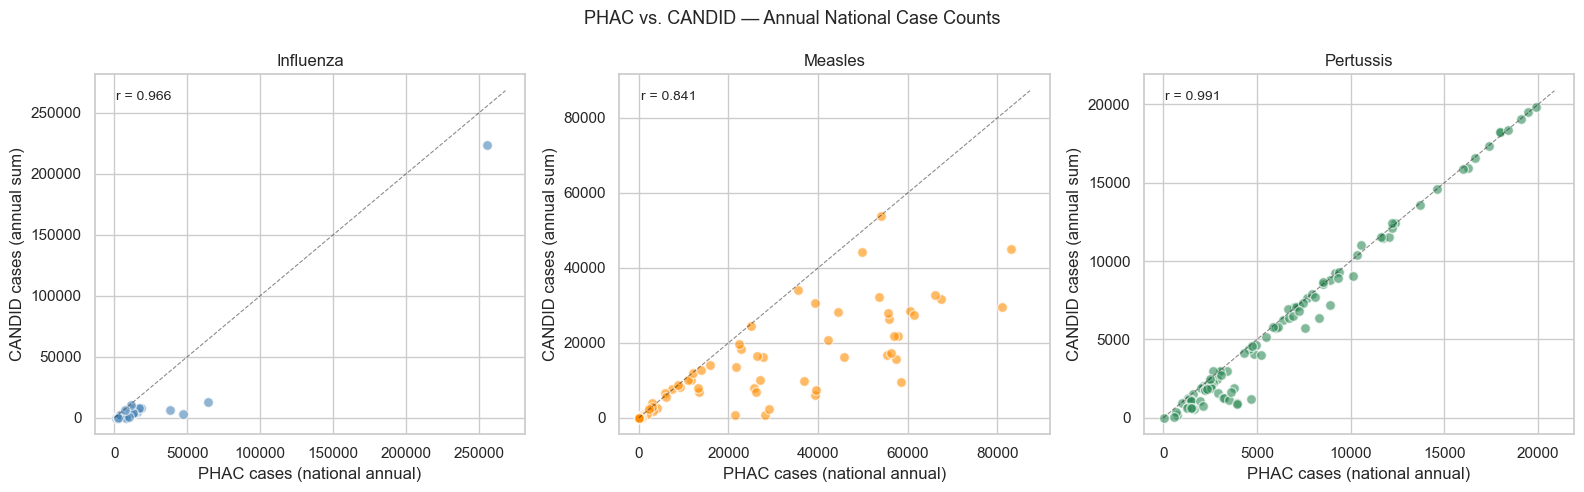

In [12]:
disease_map = {
    'influenza':      'influenza',
    'whooping-cough': 'pertussis',
    'measles':        'measles',
}

candid_focus = df[df['disease'].isin(disease_map)].copy()
candid_focus['disease_harmonized'] = candid_focus['disease'].map(disease_map)
candid_focus['year'] = candid_focus['period_start_date'].dt.year

candid_annual = (
    candid_focus.groupby(['year', 'disease_harmonized'], as_index=False)
                .agg(candid_cases=('cases_this_period', 'sum'))
                .rename(columns={'disease_harmonized': 'disease'})
)

comparison = candid_annual.merge(
    phac_clean[['year', 'disease', 'cases']].rename(columns={'cases': 'phac_cases'}),
    on=['year', 'disease'],
    how='inner'
).dropna(subset=['phac_cases'])

print(f"Overlapping year × disease pairs: {len(comparison)}")

colors = {'influenza': 'steelblue', 'measles': 'darkorange', 'pertussis': 'seagreen'}
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, disease in zip(axes, ['influenza', 'measles', 'pertussis']):
    d = comparison[comparison['disease'] == disease]
    ax.scatter(d['phac_cases'], d['candid_cases'], alpha=0.6, color=colors[disease], edgecolors='white', s=50)
    lim = max(d['phac_cases'].max(), d['candid_cases'].max()) * 1.05
    ax.plot([0, lim], [0, lim], 'k--', linewidth=0.8, alpha=0.5, label='y=x')
    ax.set_xlabel('PHAC cases (national annual)')
    ax.set_ylabel('CANDID cases (annual sum)')
    ax.set_title(disease.title())
    corr = d[['phac_cases', 'candid_cases']].corr().iloc[0, 1]
    ax.text(0.05, 0.93, f'r = {corr:.3f}', transform=ax.transAxes, fontsize=10)

plt.suptitle('PHAC vs. CANDID — Annual National Case Counts', fontsize=13)
plt.tight_layout()
plt.savefig('../reports/figures/phac_vs_candid_scatter.png', dpi=150)
plt.show()

### 9.3 Dataset Comparison Summary

| Dimension | CANDID (`canmod-cdi-normalized`) | PHAC Large Extract |
|-----------|----------------------------------|--------------------|
| Granularity | Weekly | Annual |
| Geography | Provincial (13 provinces/territories) | National aggregate |
| Coverage | 1903–2021 | 1924–2023 |
| Influenza | `influenza` key | Epidemic 1924–1958; Lab Confirmed 2000–2023 |
| Population | Per-row population field | Rate per 100,000 computed |
| Role | **Primary modeling dataset** | **Cross-validation + rate normalization** |

## 10. Go Forward Decision: CANDID Dataset of Three Diseases

**Decision:** CANDID remains the primary modeling dataset. The PHAC extract is used to:
1. Validate CANDID national aggregates are consistent with official PHAC counts
2. Provide `rate_per_100k` as a supplementary normalized feature if needed
3. Extend coverage to 2022–2023 for influenza and pertussis where CANDID ends at 2021

The processed PHAC table is saved to `data/processed/phac-clean.csv` for data organization and cleanliness.

In [13]:
import os
os.makedirs('../data/processed', exist_ok=True)

phac_clean.to_csv('../data/processed/phac-clean.csv', index=False)
print('Saved: ../data/processed/phac-clean.csv')
print(f'Shape: {phac_clean.shape}')
phac_clean.head(5)

Saved: ../data/processed/phac-clean.csv
Shape: (300, 4)


,year,cases,rate_per_100k,disease
0,1924,820.0,9.71,influenza
1,1925,1746.0,20.32,influenza
2,1926,3510.0,40.13,influenza
3,1927,1221.0,13.71,influenza
4,1928,15551.0,171.34,influenza


## 11. EDA — CANDID Focus Diseases

This section reuses variables established earlier in the notebook.
- `weekly` — CANDID filtered to `time_scale == 'wk'` with a `year` column
- `focus_diseases` — `['influenza', 'whooping-cough', 'measles']`
- `disease_map` — CANDID key → harmonized name mapping

In [14]:
# EDA Setup
focus_weekly = weekly[weekly['disease'].isin(focus_diseases)].copy()

disease_labels = {
    'influenza':      'Influenza',
    'whooping-cough': 'Pertussis (Whooping Cough)',
    'measles':        'Measles',
}
eda_colors = {
    'influenza':      'steelblue',
    'whooping-cough': 'seagreen',
    'measles':        'darkorange',
}

print("Focus disease weekly record counts:")
for d in focus_diseases:
    n = len(focus_weekly[focus_weekly['disease'] == d])
    print(f"  {disease_labels[d]}: {n:,}")

Focus disease weekly record counts:
  Influenza: 4,900
  Pertussis (Whooping Cough): 30,059
  Measles: 11,164


### 11.1 National Weekly Time Series

Aggregate all provinces to produce a single national weekly series per disease.

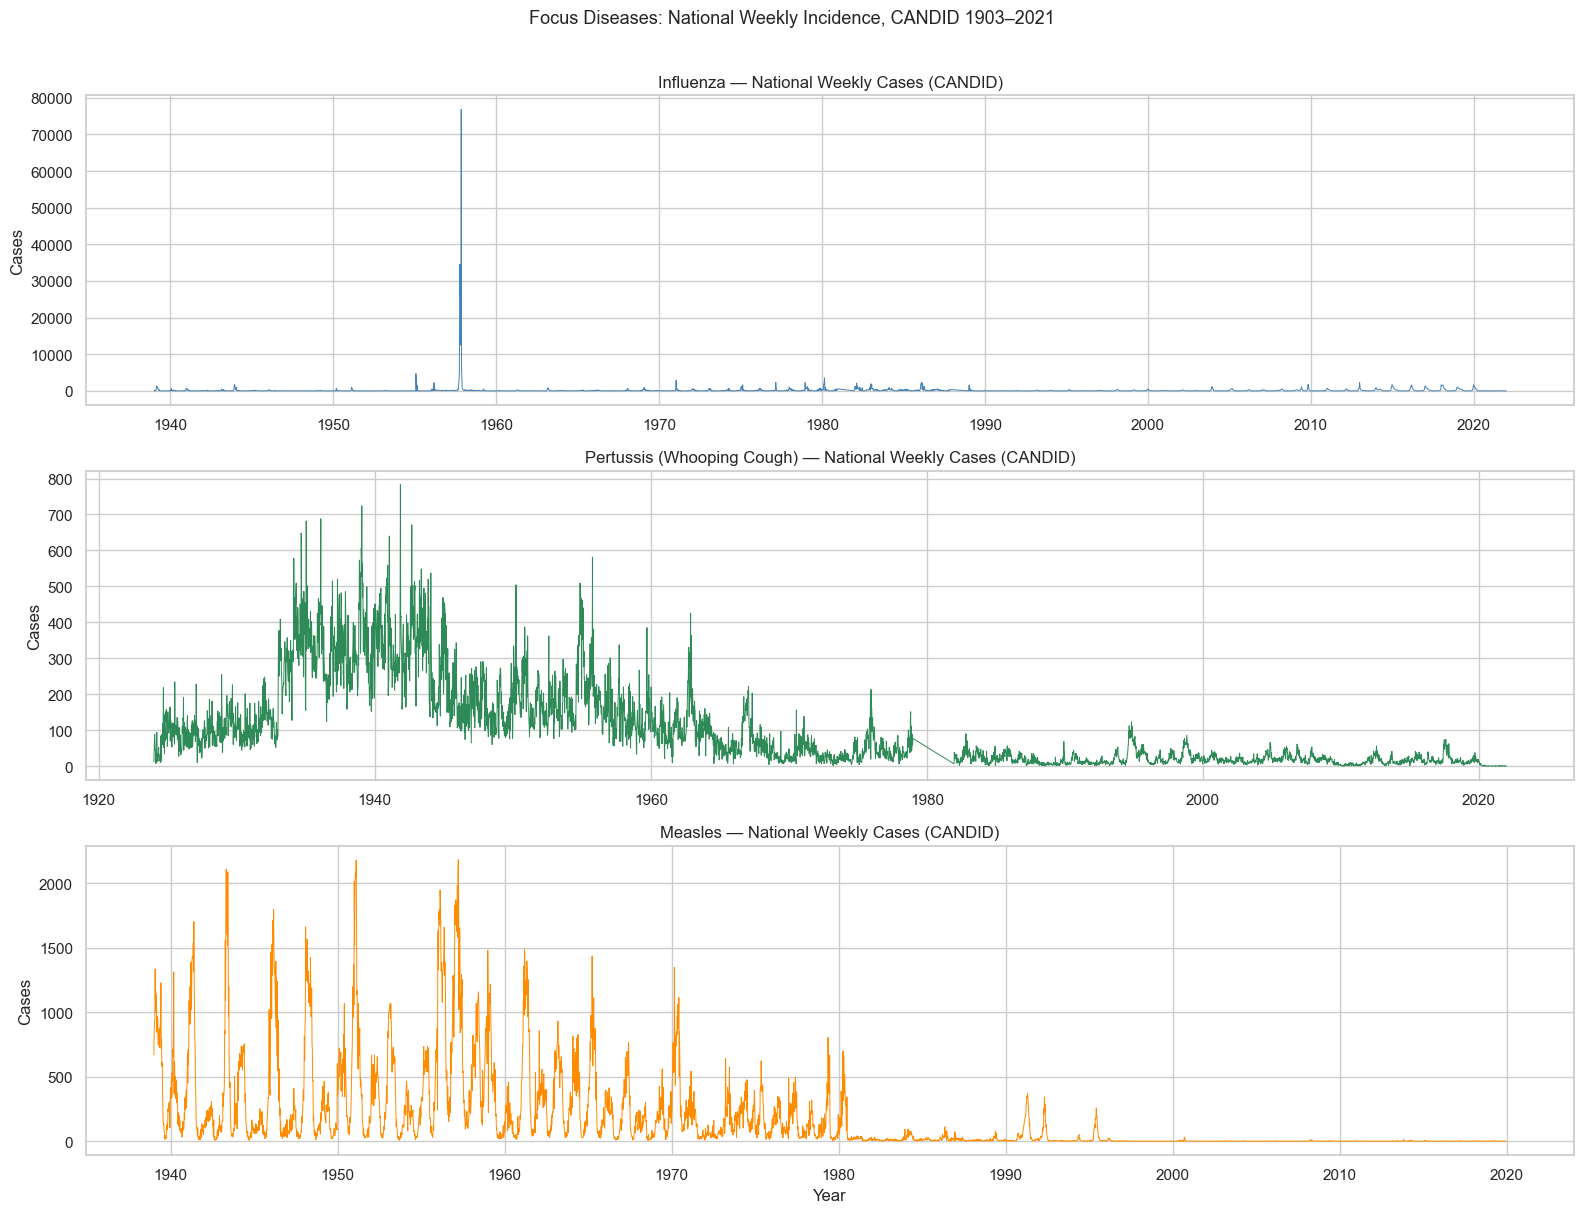

In [15]:
national_weekly = (
    focus_weekly.groupby(['disease', 'period_start_date'], as_index=False)
                .agg(cases=('cases_this_period', 'sum'))
)

fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=False)

for ax, disease in zip(axes, focus_diseases):
    d = national_weekly[national_weekly['disease'] == disease].sort_values('period_start_date')
    ax.plot(d['period_start_date'], d['cases'], linewidth=0.7, color=eda_colors[disease])
    ax.set_title(f'{disease_labels[disease]} — National Weekly Cases (CANDID)')
    ax.set_ylabel('Cases')

axes[-1].set_xlabel('Year')
plt.suptitle('Focus Diseases: National Weekly Incidence, CANDID 1903–2021', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../reports/figures/eda_national_weekly_timeseries.png', dpi=150)
plt.show()

### 11.2 Seasonality

Average weekly cases by week-of-year across all available years to expose cyclical patterns. We would expect influenza is expected to peak in winter weeks, while we would expect measles and pertussis to reflect multi-year epidemic cycles.

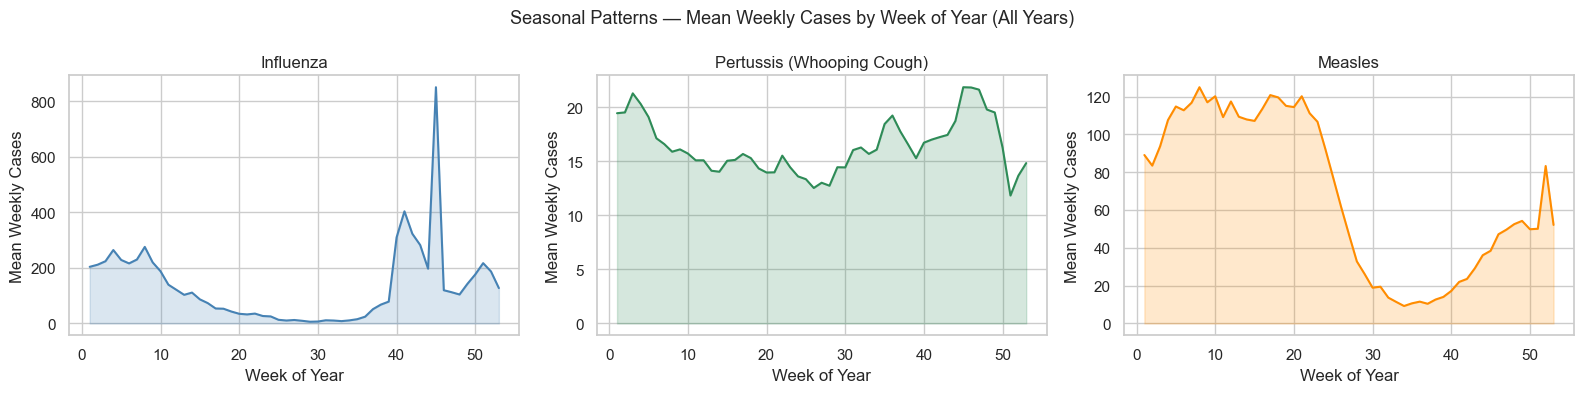

In [16]:
focus_weekly['week_of_year'] = focus_weekly['period_start_date'].dt.isocalendar().week.astype(int)

seasonal = (
    focus_weekly.groupby(['disease', 'week_of_year'])['cases_this_period']
                .mean()
                .reset_index()
                .rename(columns={'cases_this_period': 'mean_cases'})
)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, disease in zip(axes, focus_diseases):
    d = seasonal[seasonal['disease'] == disease].sort_values('week_of_year')
    ax.plot(d['week_of_year'], d['mean_cases'], color=eda_colors[disease], linewidth=1.5)
    ax.fill_between(d['week_of_year'], d['mean_cases'], alpha=0.2, color=eda_colors[disease])
    ax.set_title(disease_labels[disease])
    ax.set_xlabel('Week of Year')
    ax.set_ylabel('Mean Weekly Cases')

plt.suptitle('Seasonal Patterns — Mean Weekly Cases by Week of Year (All Years)', fontsize=13)
plt.tight_layout()
plt.savefig('../reports/figures/eda_seasonality.png', dpi=150)
plt.show()

### 11.3 Province-Level Record Breakdown

Understanding which provinces have the most weekly records per disease helps us select modeling targets. Provinces with sparse coverage will be excluded or treated carefully during train/test splits.

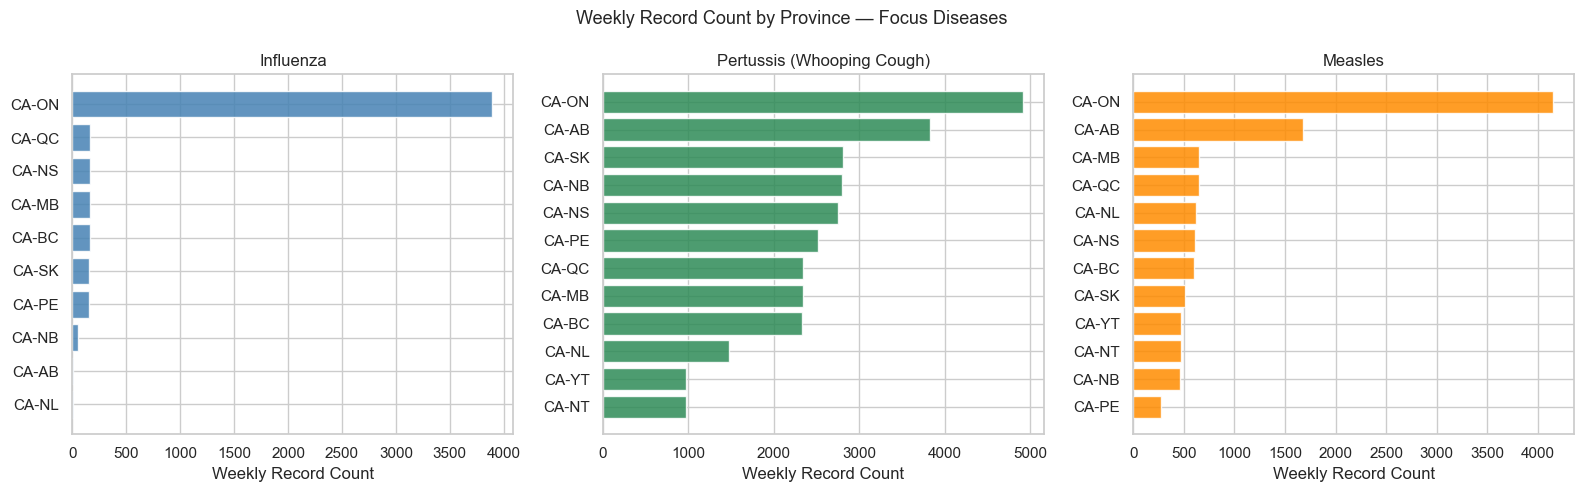

Influenza — top 3 provinces by record count:
iso_3166_2  record_count  total_cases
     CA-ON          3893     445073.0
     CA-BC           159     156579.0
     CA-MB           159      29257.0

Pertussis (Whooping Cough) — top 3 provinces by record count:
iso_3166_2  record_count  total_cases
     CA-ON          4911     208202.0
     CA-AB          3823      30767.0
     CA-SK          2811      22112.0

Measles — top 3 provinces by record count:
iso_3166_2  record_count  total_cases
     CA-ON          4149     627386.0
     CA-AB          1680      27875.0
     CA-MB           654      12584.0



In [17]:
prov_disease = (
    focus_weekly.groupby(['disease', 'iso_3166_2'])['cases_this_period']
                .agg(record_count='count', total_cases='sum')
                .reset_index()
)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, disease in zip(axes, focus_diseases):
    d = prov_disease[prov_disease['disease'] == disease].sort_values('record_count')
    ax.barh(d['iso_3166_2'], d['record_count'], color=eda_colors[disease], alpha=0.85)
    ax.set_title(disease_labels[disease])
    ax.set_xlabel('Weekly Record Count')

plt.suptitle('Weekly Record Count by Province — Focus Diseases', fontsize=13)
plt.tight_layout()
plt.savefig('../reports/figures/eda_province_breakdown.png', dpi=150)
plt.show()

# Top 3 provinces per disease
for disease in focus_diseases:
    top = (prov_disease[prov_disease['disease'] == disease]
           .nlargest(3, 'record_count')[['iso_3166_2', 'record_count', 'total_cases']])
    print(f"{disease_labels[disease]} — top 3 provinces by record count:")
    print(top.to_string(index=False))
    print()

### 11.4 Data Gaps and Coverage by Province × Year

A heatmap of weekly record counts per province per year reveals where coverage is sparse or absent (this is similar to what we ran earlier, in sections 6 and 7.)

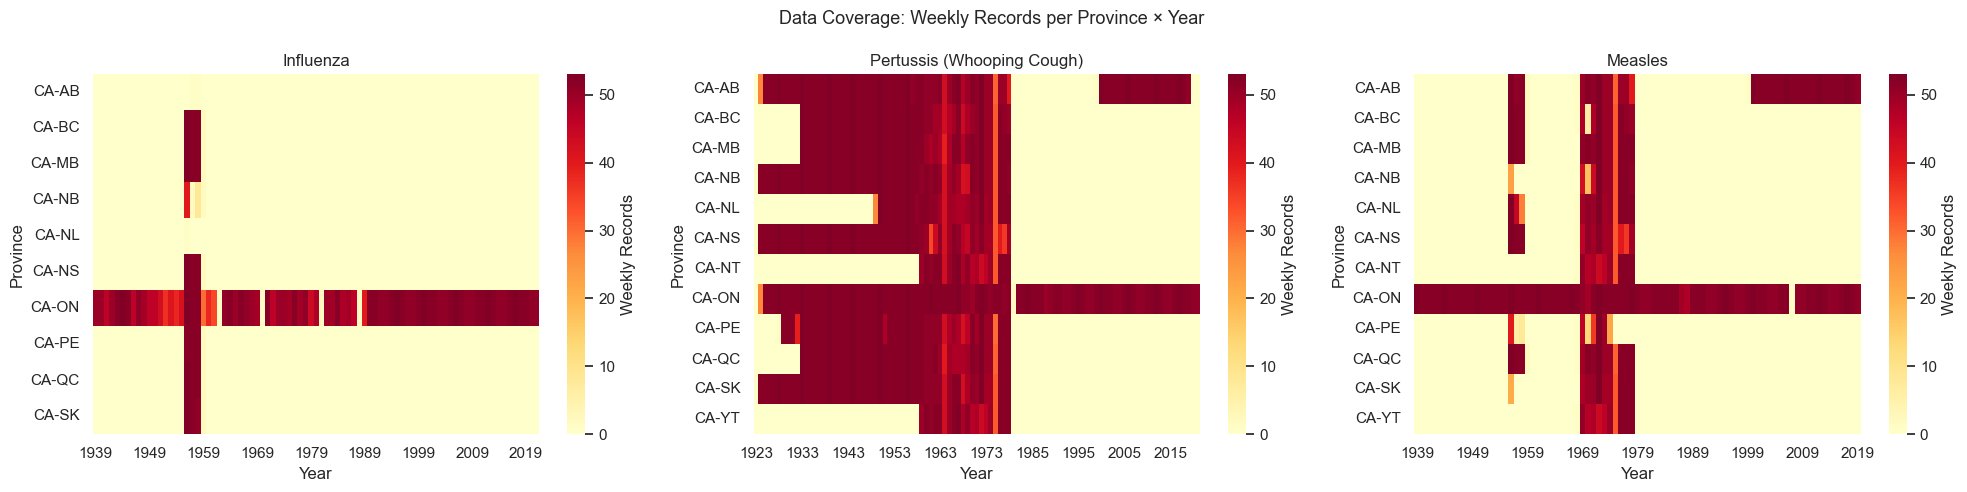

In [18]:
year_prov_counts = (
    focus_weekly.groupby(['disease', 'iso_3166_2', 'year'])['cases_this_period']
                .count()
                .reset_index()
                .rename(columns={'cases_this_period': 'n_weeks'})
)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for ax, disease in zip(axes, focus_diseases):
    d = year_prov_counts[year_prov_counts['disease'] == disease]
    pivot = d.pivot(index='iso_3166_2', columns='year', values='n_weeks').fillna(0)
    sns.heatmap(pivot, ax=ax, cmap='YlOrRd', cbar_kws={'label': 'Weekly Records'},
                linewidths=0, xticklabels=10)
    ax.set_title(disease_labels[disease])
    ax.set_xlabel('Year')
    ax.set_ylabel('Province')

plt.suptitle('Data Coverage: Weekly Records per Province × Year', fontsize=13)
plt.tight_layout()
plt.savefig('../reports/figures/eda_coverage_heatmap.png', dpi=150)
plt.show()

### 11.5 Descriptive Statistics

Summary statistics for weekly case counts per disease.

In [19]:
desc = (
    focus_weekly.groupby('disease')['cases_this_period']
                .describe()
                .rename(index=disease_labels)
                .round(1)
)

print("Descriptive Statistics — Weekly Cases by Disease (CANDID, all provinces)")
desc

Descriptive Statistics — Weekly Cases by Disease (CANDID, all provinces)


,count,mean,std,min,25%,50%,75%,max
disease,,,,,,,,
Influenza,4900.0,136.3,1206.8,0.0,1.0,12.0,70.0,72072.0
Measles,11163.0,68.5,191.0,0.0,0.0,3.0,35.0,2181.0
Pertussis (Whooping Cough),30057.0,16.4,33.6,0.0,0.0,3.0,16.0,562.0


### 11.6 Autocorrelation Structure (ACF/PACF)

ACF and PACF plots on the national weekly series directly inform model design:
- **ACF** shows overall temporal dependence and seasonality lags
- **PACF** reveals the direct lag relationships that inform ARIMA order selection

We plot 52 lags (one full year) on the national aggregated series per disease. Gaps in the series are filled with zero for the purposes of this analysis.

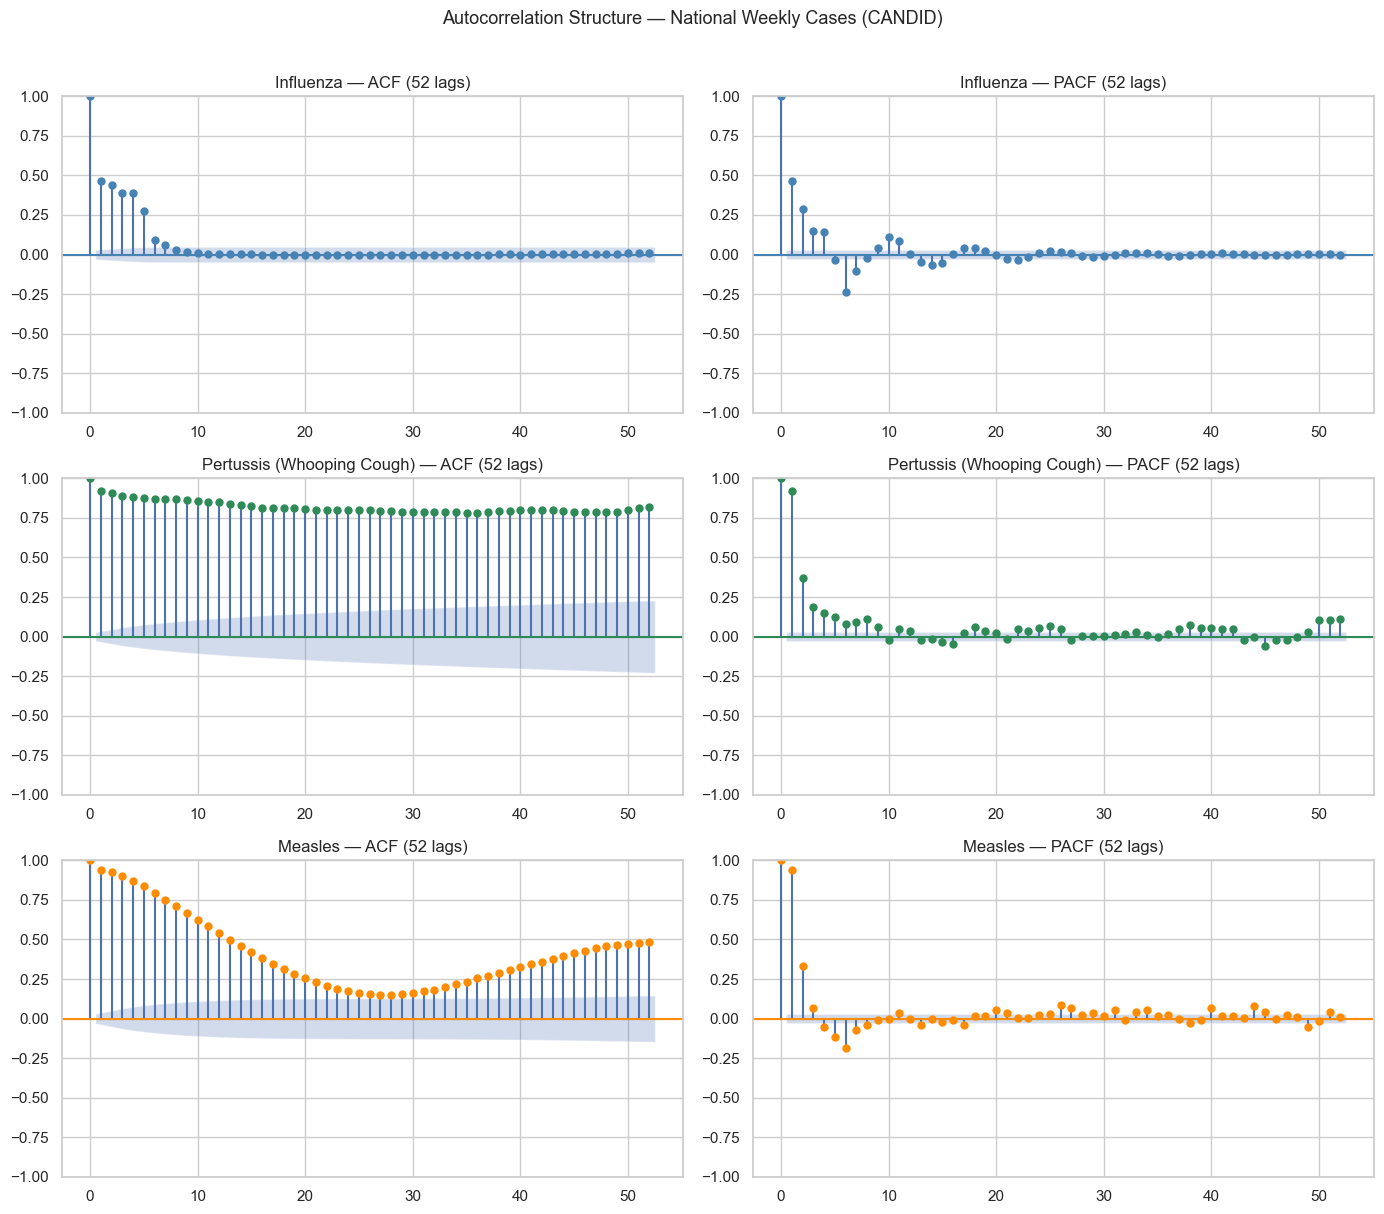

In [20]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(3, 2, figsize=(14, 12))

for i, disease in enumerate(focus_diseases):
    series = (
        national_weekly[national_weekly['disease'] == disease]
        .set_index('period_start_date')['cases']
        .resample('W').sum()
        .fillna(0)
    )
    plot_acf(series, lags=52, ax=axes[i, 0], color=eda_colors[disease],
             title=f'{disease_labels[disease]} — ACF (52 lags)')
    plot_pacf(series, lags=52, ax=axes[i, 1], color=eda_colors[disease],
              title=f'{disease_labels[disease]} — PACF (52 lags)')

plt.suptitle('Autocorrelation Structure — National Weekly Cases (CANDID)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../reports/figures/eda_acf_pacf.png', dpi=150)
plt.show()

### 12. Data Split

Time-Series Data Split  (70% Train / 15% Validation / 15% Test)
Applied to the primary CANDID dataset

For time-series forecasting, splits must be strictly chronological to prevent data leakage. Boundaries are placed at year edges to avoid splitting multi-week or multi-month reporting periods across sets.

- CANDID date range : 1903-01-01 → 2021-12-26  (~119 years)
- Train  cutoff     : period_start_date <  1986-01-01  (83 yrs  ≈ 70%)
- Val    cutoff     : period_start_date <  2004-01-01  (18 yrs  ≈ 15%)
- Test              : period_start_date >= 2004-01-01  (18 yrs  ≈ 15%)


In [21]:

import pandas as pd

TRAIN_CUTOFF = pd.Timestamp("1986-01-01")
VAL_CUTOFF   = pd.Timestamp("2004-01-01")

def assign_split(date):
    if date < TRAIN_CUTOFF:
        return "train"
    elif date < VAL_CUTOFF:
        return "validation"
    else:
        return "test"

df["split"] = df["period_start_date"].apply(assign_split)

# ── Verification ──────────────────────────────────────────────────────────────
print("=" * 65)
print("CANDID Dataset — Chronological Train / Validation / Test Split")
print("=" * 65)

for s in ["train", "validation", "test"]:
    subset   = df[df["split"] == s]
    n        = len(subset)
    pct      = n / len(df) * 100
    yr_min   = subset["period_start_date"].min().strftime("%Y-%m-%d")
    yr_max   = subset["period_start_date"].max().strftime("%Y-%m-%d")
    diseases = subset["disease"].nunique()
    provs    = subset["iso_3166_2"].nunique()
    print(f"\n  {s.upper():<12}")
    print(f"    Rows         : {n:>9,}  ({pct:.1f}%)")
    print(f"    Date range   : {yr_min}  →  {yr_max}")
    print(f"    Diseases     : {diseases}")
    print(f"    Provinces    : {provs}")

print(f"\n  TOTAL ROWS: {len(df):,}")
print("=" * 65)

CANDID Dataset — Chronological Train / Validation / Test Split

  TRAIN       
    Rows         :   700,883  (75.0%)
    Date range   : 1903-01-01  →  1985-12-29
    Diseases     : 170
    Provinces    : 12

  VALIDATION  
    Rows         :   103,774  (11.1%)
    Date range   : 1986-01-05  →  2003-12-28
    Diseases     : 132
    Provinces    : 13

  TEST        
    Rows         :   129,353  (13.8%)
    Date range   : 2004-01-01  →  2021-12-26
    Diseases     : 204
    Provinces    : 13

  TOTAL ROWS: 934,010


In [22]:
df.head()

,iso_3166,iso_3166_2,period_start_date,period_end_date,disease,nesting_disease,basal_disease,cases_this_period,location,location_type,time_scale,historical_disease,historical_disease_family,historical_disease_subclass,days_this_period,period_mid_date,population,record_origin,original_dataset_id,digitization_id,scan_id,split
0,CA,CA-ON,1903-01-01,1903-01-31,smallpox,NaN,smallpox,196.0,ONT.,province,mo,Small-pox,NaN,NaN,31,1903-01-16,2252721,historical,cdi_on_1903-1939_mn,cdi_mort_on_1903-1939_mn,cdi_on_1903-1939_mn,train
1,CA,CA-ON,1903-01-01,1903-01-31,scarlet-fever,NaN,scarlet-fever,500.0,ONT.,province,mo,Scarlatina,NaN,NaN,31,1903-01-16,2252721,historical,cdi_on_1903-1939_mn,cdi_mort_on_1903-1939_mn,cdi_on_1903-1939_mn,train
2,CA,CA-ON,1903-01-01,1903-01-31,diphtheria,NaN,diphtheria,510.0,ONT.,province,mo,Diphtheria,NaN,NaN,31,1903-01-16,2252721,historical,cdi_on_1903-1939_mn,cdi_mort_on_1903-1939_mn,cdi_on_1903-1939_mn,train
3,CA,CA-ON,1903-01-01,1903-01-31,measles,NaN,measles,6.0,ONT.,province,mo,Measles,NaN,NaN,31,1903-01-16,2252721,historical,cdi_on_1903-1939_mn,cdi_mort_on_1903-1939_mn,cdi_on_1903-1939_mn,train
4,CA,CA-ON,1903-01-01,1903-01-31,whooping-cough,NaN,whooping-cough,9.0,ONT.,province,mo,Whooping cough,NaN,NaN,31,1903-01-16,2252721,historical,cdi_on_1903-1939_mn,cdi_mort_on_1903-1939_mn,cdi_on_1903-1939_mn,train


In [23]:
# Save Processed CANDID Dataset with Split Column

OUTPUT_PATH = '../data/processed/candid_data_split.csv'
df.to_csv(OUTPUT_PATH, index=False)

print(f"Saved : {OUTPUT_PATH}")
print(f"Shape : {df.shape}")
print(f"Columns ({len(df.columns)}): {list(df.columns)}")
print(f"\nSplit column value counts:")
print(df["split"].value_counts().reindex(["train", "validation", "test"]))

Saved : ../data/processed/candid_data_split.csv
Shape : (934010, 22)
Columns (22): ['iso_3166', 'iso_3166_2', 'period_start_date', 'period_end_date', 'disease', 'nesting_disease', 'basal_disease', 'cases_this_period', 'location', 'location_type', 'time_scale', 'historical_disease', 'historical_disease_family', 'historical_disease_subclass', 'days_this_period', 'period_mid_date', 'population', 'record_origin', 'original_dataset_id', 'digitization_id', 'scan_id', 'split']

Split column value counts:
split
train         700883
validation    103774
test          129353
Name: count, dtype: int64
